# Understanding the Data
Exploratory Data Analysis on the Titanic Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

## 1. How BIG is this data?

In [3]:
df.shape

(891, 12)

## 2. What does the Data LOOK like?

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.sample(5) # to see data randomly, not biased data (in a pattern and grouping)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
314,315,0,2,"Hart, Mr. Benjamin",male,43.0,1,1,F.C.C. 13529,26.2500,NaN,S
773,774,0,3,"Elias, Mr. Dibo",male,NaN,0,0,2674,7.2250,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
343,344,0,2,"Sedgwick, Mr. Charles Frederick Waddington",male,25.0,0,0,244361,13.0000,NaN,S
200,201,0,3,"Vande Walle, Mr. Nestor Cyriel",male,28.0,0,0,345770,9.5000,NaN,S


## 3. What is the DATATYPE of the cols?

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# df['Age'] = df['Age'].convert_dtypes('int64') # astype caused error, In this, NA values are converted to pd.NA

## 4. Are there any MISSING values ?

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 5. How does the data look MATHEMATICALLY?

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 6. Are there any DUPLICATE values ?

In [10]:
df.duplicated().sum()

np.int64(0)

## 7. How is the correlation between columns?

In [11]:
df.corr(numeric_only=True)['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

# EDA (Univariate)

In [12]:
import seaborn as sns

## Categorical Data

### 1. Countplot
for frequency

<Axes: xlabel='Survived', ylabel='count'>

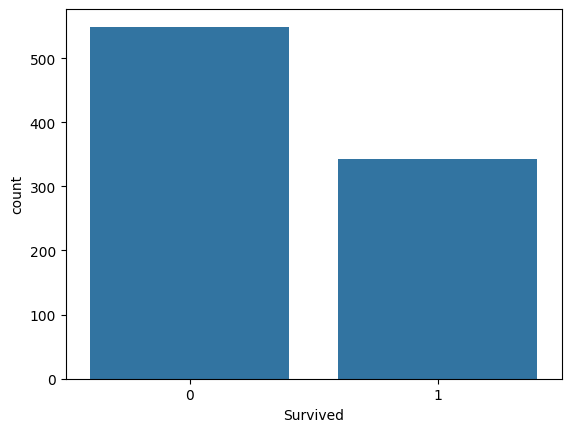

In [13]:
sns.countplot(x=df['Survived']) # frequency count, same as value_counts in pandas

In [14]:
# pd.value_counts(df['Survived']) # depricated
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

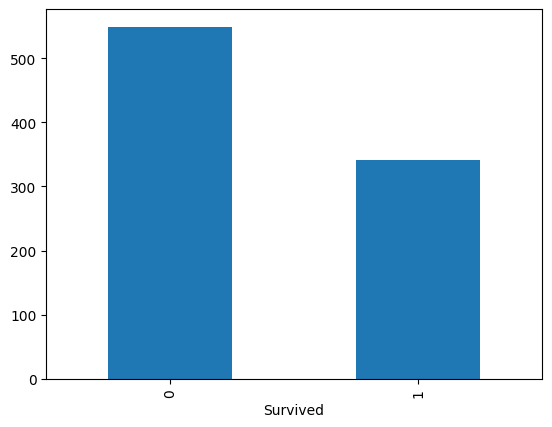

In [15]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Pclass', ylabel='count'>

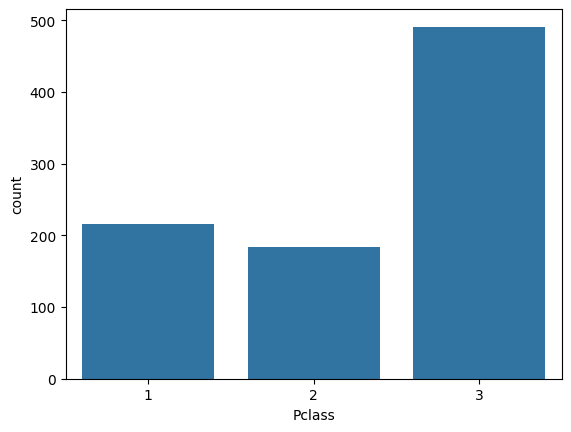

In [16]:
sns.countplot(x=df['Pclass'])

<Axes: xlabel='Sex', ylabel='count'>

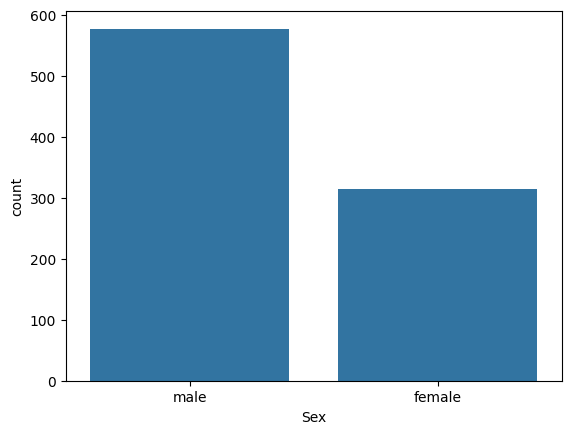

In [17]:
sns.countplot(x=df['Sex'])

<Axes: xlabel='Embarked', ylabel='count'>

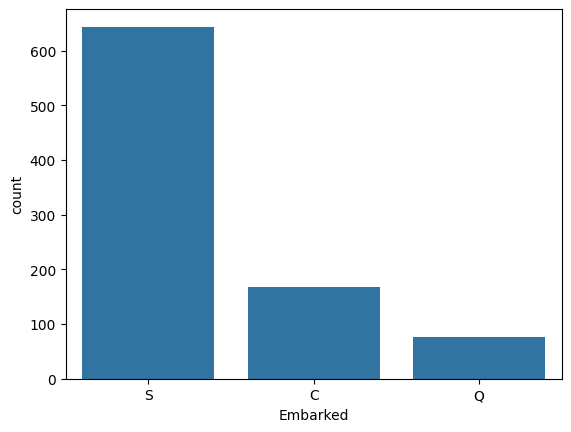

In [18]:
sns.countplot(x=df['Embarked'])

### 2. PieChart
for frequency in %

<Axes: ylabel='count'>

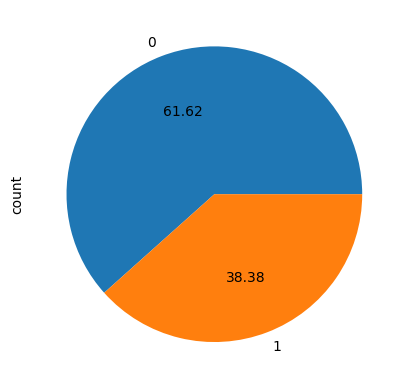

In [19]:
df['Survived'].value_counts().plot(kind='pie', autopct='%.2f')

<Axes: ylabel='count'>

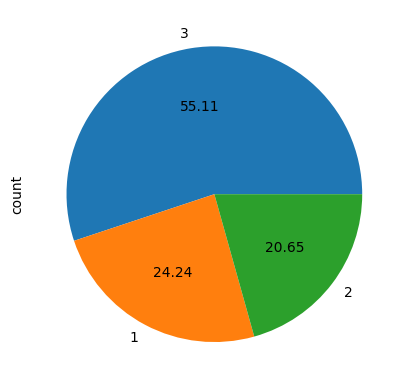

In [20]:
df['Pclass'].value_counts().plot(kind='pie', autopct='%.2f')

<Axes: ylabel='count'>

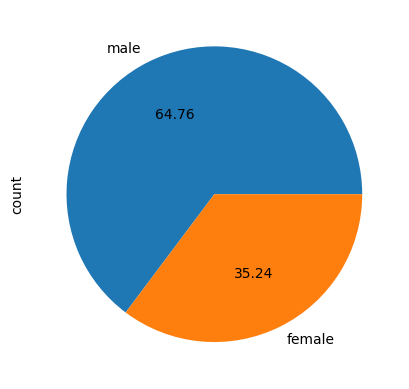

In [21]:
df['Sex'].value_counts().plot(kind='pie', autopct='%.2f')

## Numerical Data

### 1. Histplot

In [22]:
import matplotlib.pyplot as plt

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

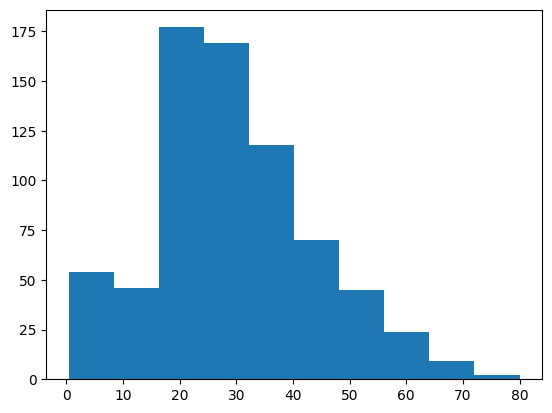

In [25]:
plt.hist(df['Age'], bins=10)

### 2. Distplot

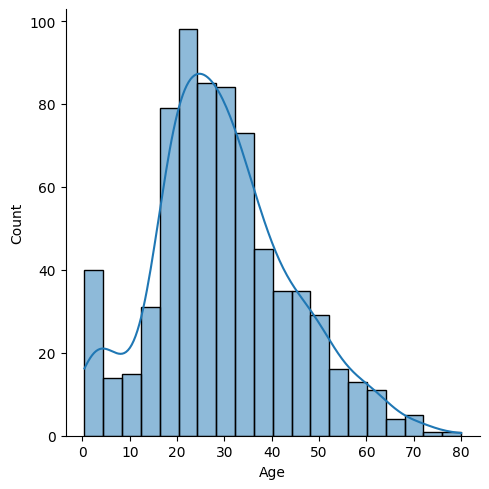

In [30]:
# sns.distplot(df['Age']) # depricated
sns.displot(df['Age'], kde=True)

### 3. Boxplot

<Axes: xlabel='Age'>

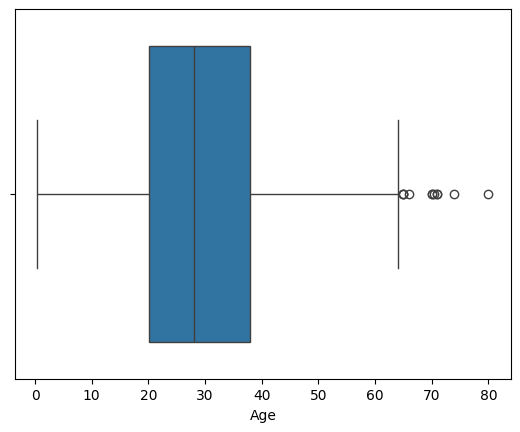

In [34]:
sns.boxplot(x=df['Age'])

<Axes: xlabel='Fare'>

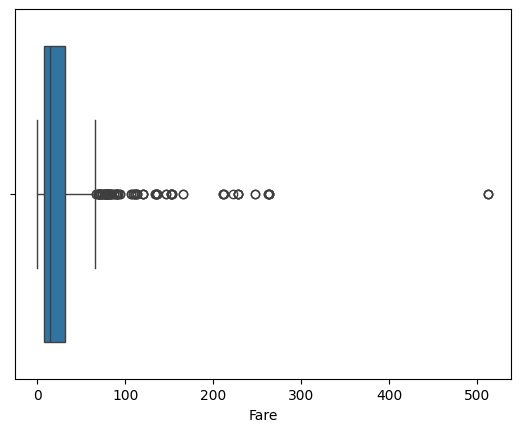

In [33]:
sns.boxplot(x=df['Fare'])

<Axes: xlabel='Age'>

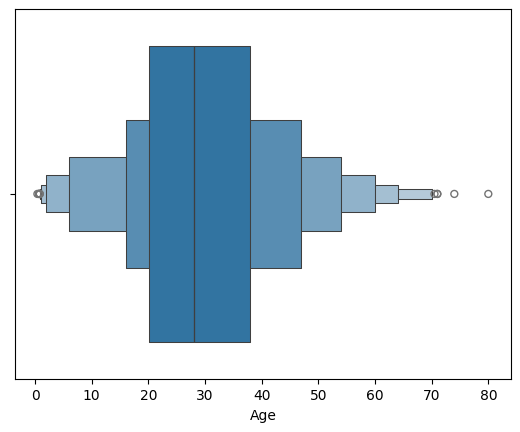

In [36]:
sns.boxenplot(x=df['Age'])